# 5주차_데이터 탐색과 시각화 Ⅱ


- 관계 시각화


---

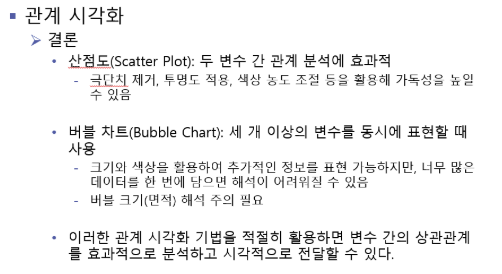

In [1]:
# 필요한 패키지 설치

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
# 데이터 분석과 시각화에 필요한 주요 라이브러리 불러오기
# matplotlib: 시각화, pandas: 데이터프레임 처리, seaborn: 통계적 시각화, numpy: 수치 계산

plt.rcParams['figure.dpi'] = 300
# 전체 matplotlib 그래프의 해상도를 300DPI로 설정하여 고화질 출력이 가능하도록 함


In [3]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/karthickveerakumar/startup-logistic-regression
df = pd.read_csv("../..//main/datasets/50_Startups.csv")

# 데이터 샘플 확인
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [5]:
df.shape

(50, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [7]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [8]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [ ]:
df.select_dtypes(include=['number']).skew()
# 데이터프레임(df)에서 수치형(numeric) 컬럼들만 선택하여 각각의 왜도(Skewness)를 계산함
# 왜도(Skewness)는 분포의 비대칭 정도를 나타내는 통계량으로, 정규분포를 기준으로 좌우로 얼마나 치우쳐 있는지를 측정함

# ✔️ 해석 기준:
# - 왜도 = 0: 완전히 대칭인 분포 (정규분포와 유사)
# - 왜도 > 0: 오른쪽으로 꼬리가 긴 분포 (우측 비대칭, 고수익 소수 스타트업이 존재할 수 있음)
# - 왜도 < 0: 왼쪽으로 꼬리가 긴 분포 (좌측 비대칭, 예외적으로 낮은 값 존재)

# ✔️ 활용 목적:
# - 왜도가 높거나 낮으면 데이터가 정규분포가 아니므로, 회귀 모델 성능 저하 요인이 될 수 있음
# - 로그 변환(log transform), Box-Cox 변환 등으로 정규성 개선을 고려할 수 있음

R&D Spend          0.164002
Administration    -0.489025
Marketing Spend   -0.046472
Profit             0.023291
dtype: float64

In [ ]:
df.select_dtypes(include=['number']).kurt()
# 데이터프레임(df)에서 수치형(numeric) 컬럼만 선택한 뒤, 각 컬럼에 대해 첨도(kurtosis)를 계산함
# 첨도는 데이터 분포의 '뾰족함(peak)' 또는 '꼬리의 두꺼움(tail heaviness)' 정도를 수치화하는 지표임

# pandas의 .kurt() 함수는 기본적으로 'Excess Kurtosis(초과 첨도)'를 계산함
# 초과 첨도는 정규분포의 첨도(3)를 기준으로 3을 뺀 값 → 정규분포의 경우 0이 기준이 됨

# ✔️ 첨도 해석 기준:
# - 첨도 ≈ 0: 정규분포 수준의 뾰족함 (기준치)
# - 첨도 > 0: 뾰족한 분포 (Leptokurtic) → 중심값 주변에 데이터가 몰려 있고 극단값(꼬리)이 더 많음
# - 첨도 < 0: 평평한 분포 (Platykurtic) → 중심은 낮고, 분포가 넓게 퍼져 있음 (극단값 적음)

# 첨도 값은 분산, 왜도와 함께 데이터 분포의 형태를 분석할 때 유용하게 활용됨


R&D Spend         -0.761465
Administration     0.225071
Marketing Spend   -0.671701
Profit            -0.063859
dtype: float64

In [ ]:
df.select_dtypes(include=['number']).cov()
# 데이터프레임(df)에서 수치형(numeric) 컬럼만 선택한 후, 이들 간의 공분산 행렬을 계산함

# ✔️ 공분산(Covariance)이란?
# 두 수치형 변수 간의 **선형 관계 방향과 강도**를 측정하는 통계 지표임
# 
# 수학적으로는 다음과 같이 계산됨:
#     cov(X, Y) = E[(X - μ_X) * (Y - μ_Y)]
#     → 평균으로부터 각각 얼마나 떨어져 있는지를 곱한 값들의 평균
#
# ✔️ 해석 기준:
# - cov(X, Y) > 0: 두 변수가 **같은 방향**으로 움직임 (한쪽이 증가하면 다른 쪽도 증가)
# - cov(X, Y) < 0: 두 변수가 **반대 방향**으로 움직임 (한쪽이 증가하면 다른 쪽은 감소)
# - cov(X, Y) ≈ 0: 두 변수 간 선형적 관계가 거의 없음

# ⚠️ 주의할 점:
# - 공분산 값은 변수의 단위(scale)에 영향을 받기 때문에 크기의 절대값만으로 변수 간 관계를 비교하기는 어려움
#   예: 단위가 원(₩) vs. 퍼센트(%)일 경우, 공분산 값 자체는 직접 비교 불가
# → 이런 이유로 일반적으로는 상관계수(corr())와 함께 해석함


,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,2.107017e+09,3.111739e+08,4.065495e+09,1.800007e+09
Administration,3.111739e+08,7.849973e+08,-1.101690e+08,2.266673e+08
Marketing Spend,4.065495e+09,-1.101690e+08,1.495492e+10,3.685779e+09
Profit,1.800007e+09,2.266673e+08,3.685779e+09,1.624588e+09


In [ ]:
df.select_dtypes(include=['number']).corr()
# 데이터프레임(df)에서 수치형(numeric) 컬럼만 선택한 후, 이들 간의 **상관계수 행렬**을 계산함

# ✔️ 상관계수(Correlation Coefficient)란?
# 두 변수 간 **선형적 관계의 강도와 방향**을 나타내는 통계 지표임
# 
# 기본적으로 '피어슨 상관계수 (Pearson Correlation)'를 계산함
# 계산식: corr(X, Y) = cov(X, Y) / (σ_X * σ_Y)
# → 공분산을 각 변수의 표준편차로 나눈 값 → 단위가 제거됨 → [-1, 1] 범위로 정규화됨

# ✔️ 상관계수 해석 기준:
# - 1.0: 완전한 **양의 상관관계** → X 증가 시 Y도 일정하게 증가
# - 0.0: **선형적 관계 없음** → X와 Y가 아무 관련 없이 움직일 가능성이 높음
# - -1.0: 완전한 **음의 상관관계** → X 증가 시 Y는 일정하게 감소

# ✔️ 실무에서의 활용 예:
# - 변수 간의 중복 여부(다중공선성) 확인
# - 특징 선택(feature selection)
# - 예측 모델의 설명력 해석

# ⚠️ 주의:
# 상관계수는 **선형 관계만 반영**함.  
# 비선형 관계가 있을 경우, 상관계수는 낮게 나와도 두 변수는 관계가 있을 수 있음.


,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


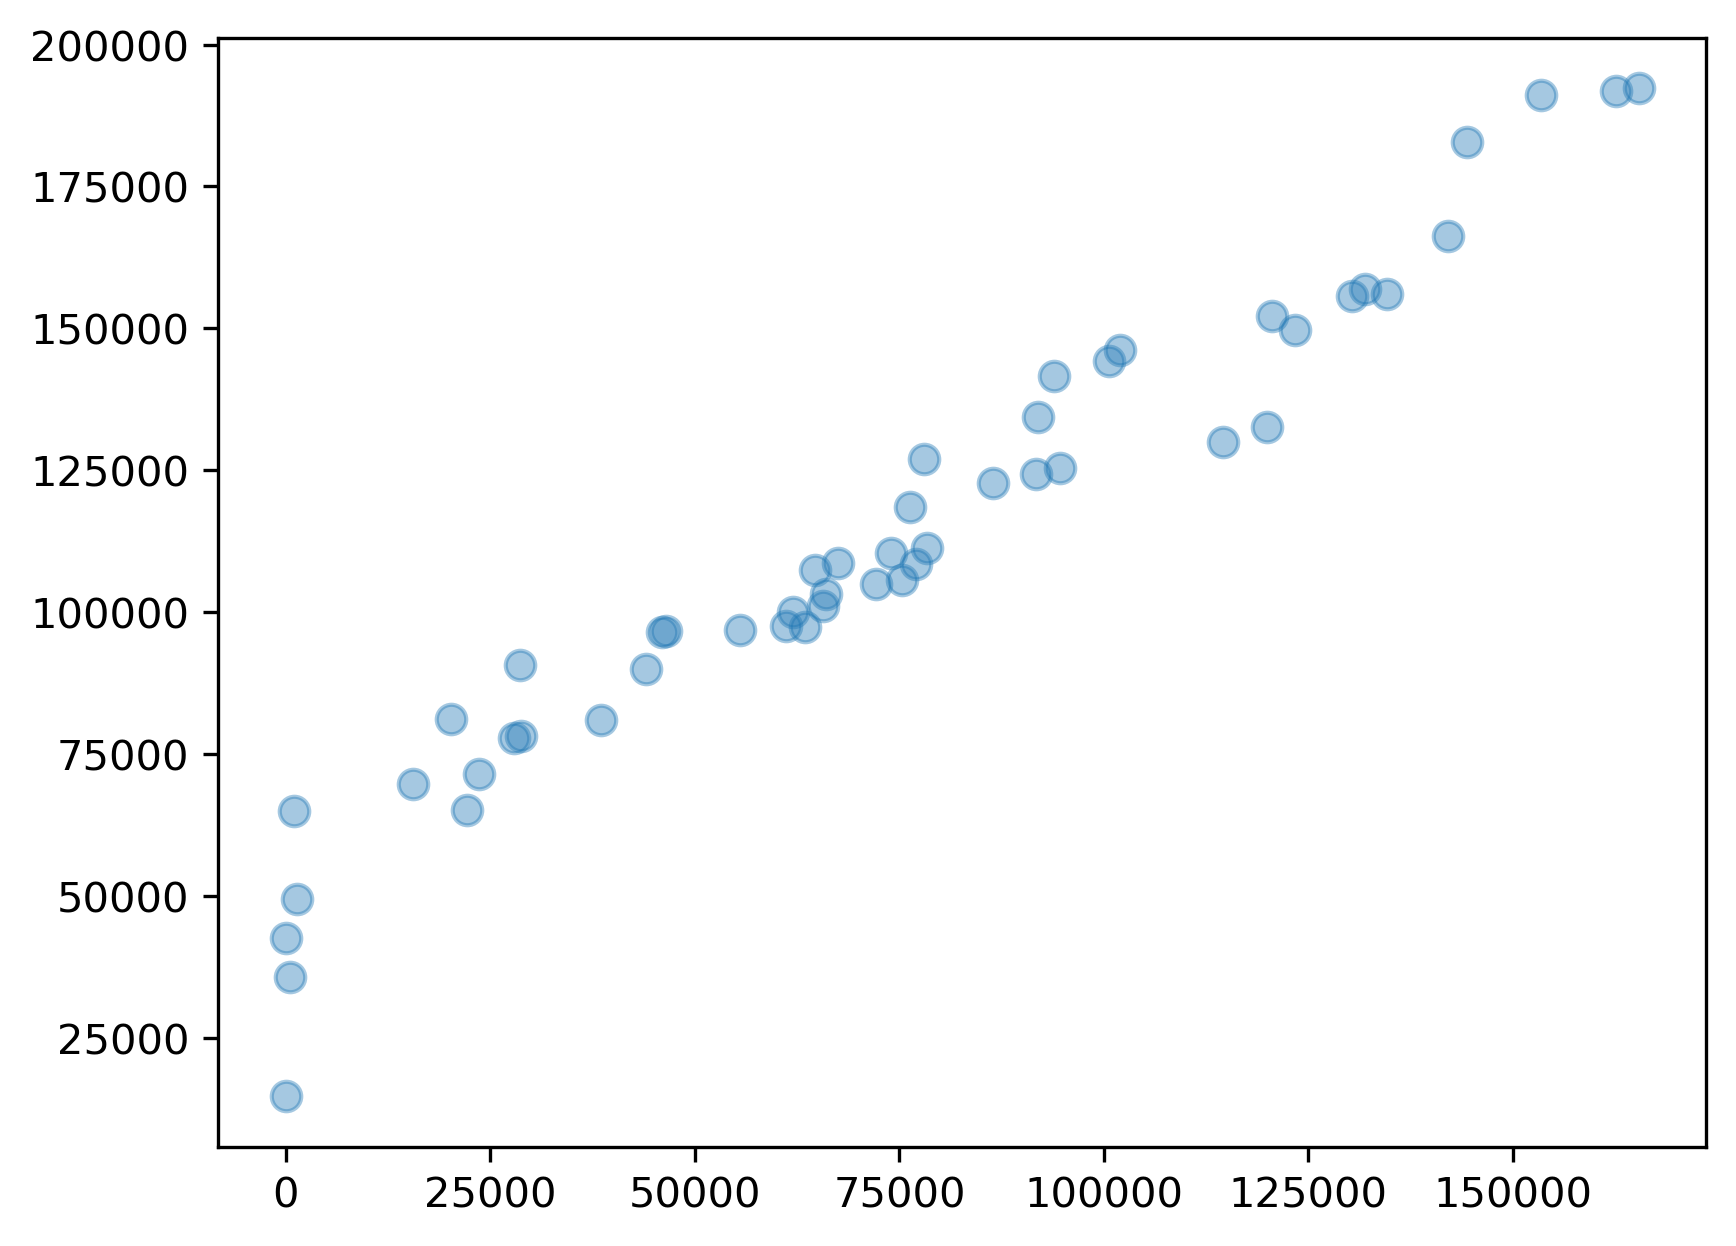

In [ ]:
# 기본 산점도 시각화

plt.scatter(df['R&D Spend'], df['Profit'], s=50, alpha=0.4)
# 기본 산점도(Scatter Plot)를 생성함
# x축: 'R&D Spend' (연구개발 비용) → 독립변수로 설정
# y축: 'Profit' (이익) → 종속변수로 설정
# 각 점은 하나의 기업(행)을 의미함
#
# s=50 → 각 점의 크기를 고정된 50 크기로 설정함 (기본보다 약간 크게 보임)
# alpha=0.4 → 투명도를 40%로 설정하여 데이터가 겹칠 때도 구조가 보이도록 처리함
#             여러 점이 중복되거나 밀집된 경우, 겹침이 시각적으로 드러남 (밀도 파악 용이)

plt.show()
# matplotlib에서 작성한 그래프를 출력함
# Jupyter 환경에서는 생략해도 출력되지만, 코드 가독성과 확장성을 위해 명시적으로 작성하는 것이 좋음

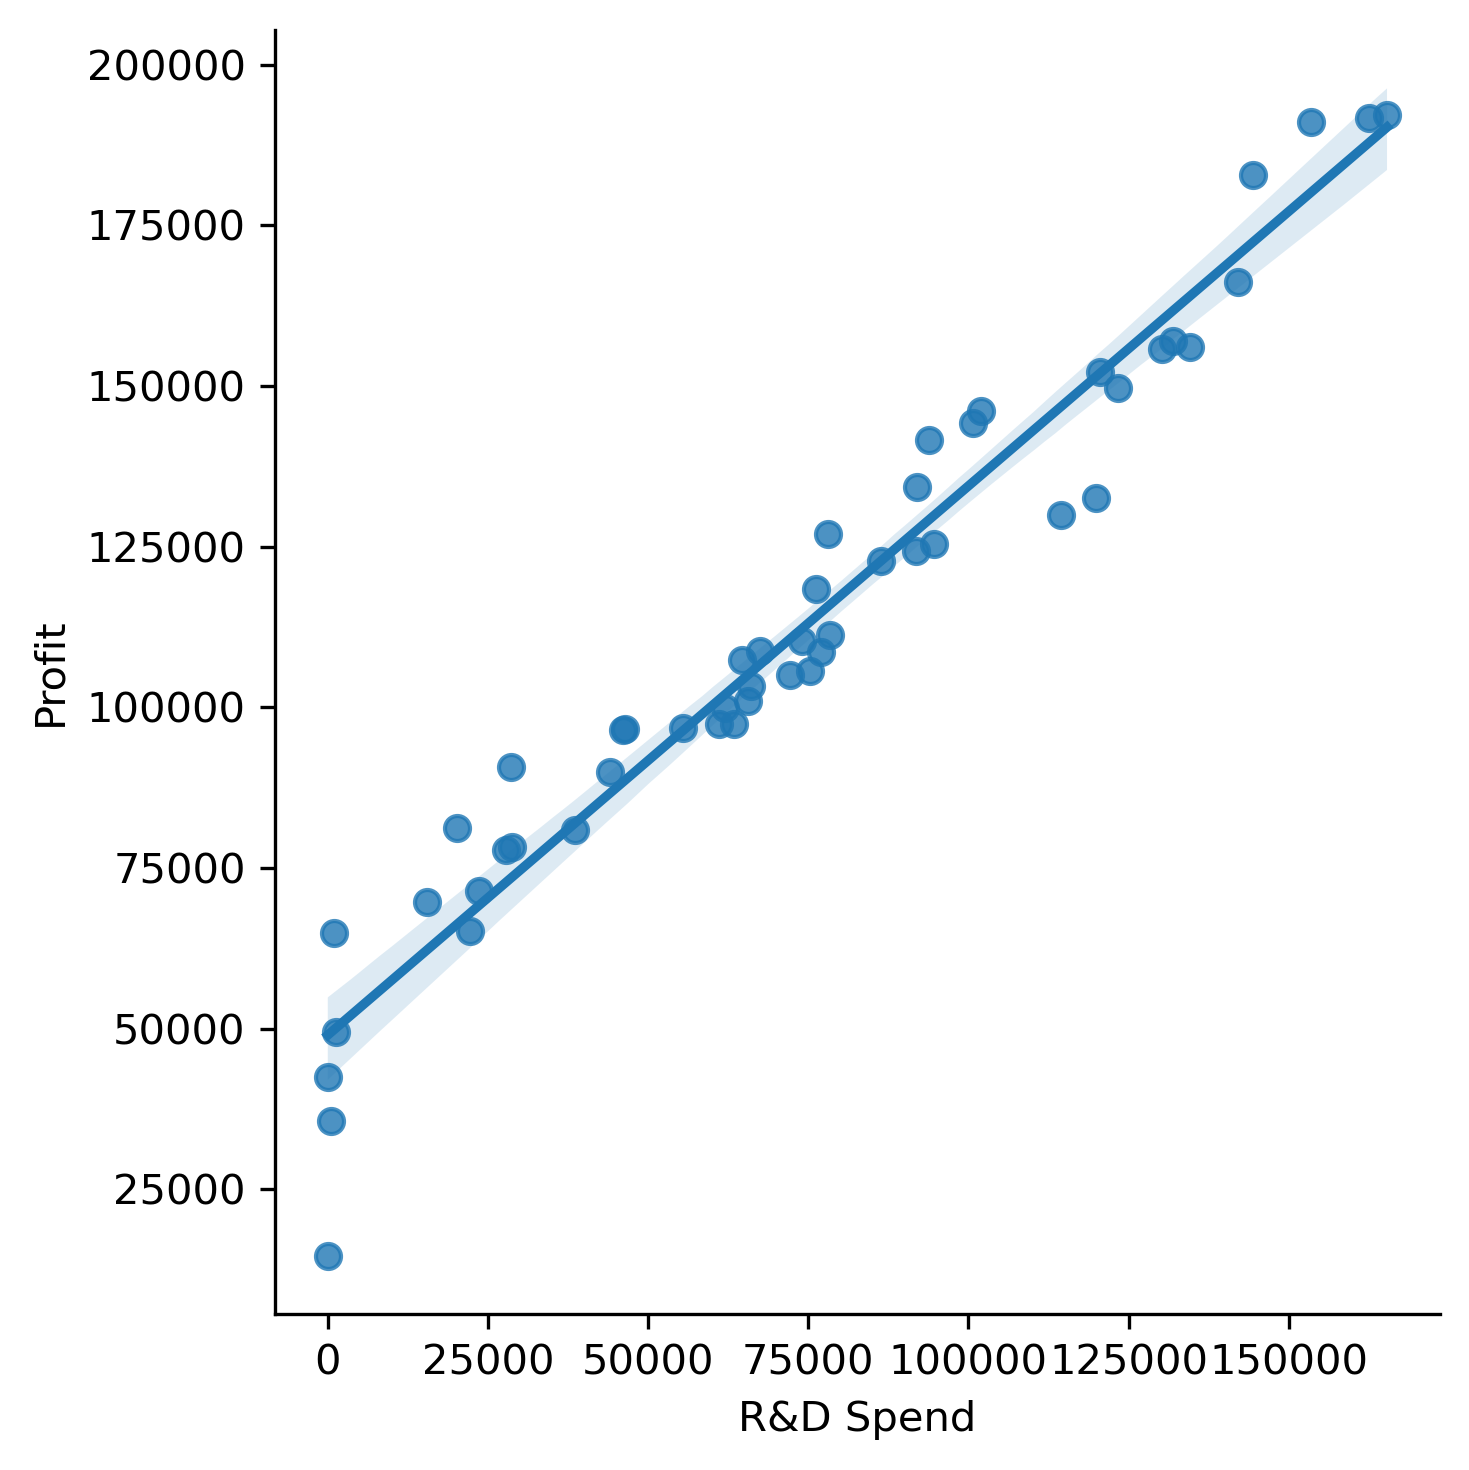

In [ ]:
ax = sns.lmplot(x='R&D Spend', y='Profit', data=df)
# seaborn의 lmplot(linear model plot)을 사용하여 산점도와 선형 회귀선을 함께 시각화함
# x축: 'R&D Spend' (연구개발 비용)
# y축: 'Profit' (순이익)
# data=df → 입력 데이터프레임 지정

# ✔️ lmplot 기능 요약:
# 1. 개별 데이터 포인트를 산점도로 표시함
# 2. x와 y 변수 간 **선형 회귀선(line of best fit)** 을 자동으로 추가함
# 3. 회귀선 주변에 **신뢰 구간(기본 95%)** 을 음영으로 표시함 → 추정의 불확실성 표현
# 4. 기본적으로 **groupby 카테고리별 회귀선 분리**도 가능함 (`hue` 옵션 사용 시)

# 반환 객체는 `FacetGrid`이며, 단순 matplotlib Axes가 아님
# → 추가적인 커스터마이징은 `ax.ax` 또는 `FacetGrid.map()` 형태로 접근해야 함


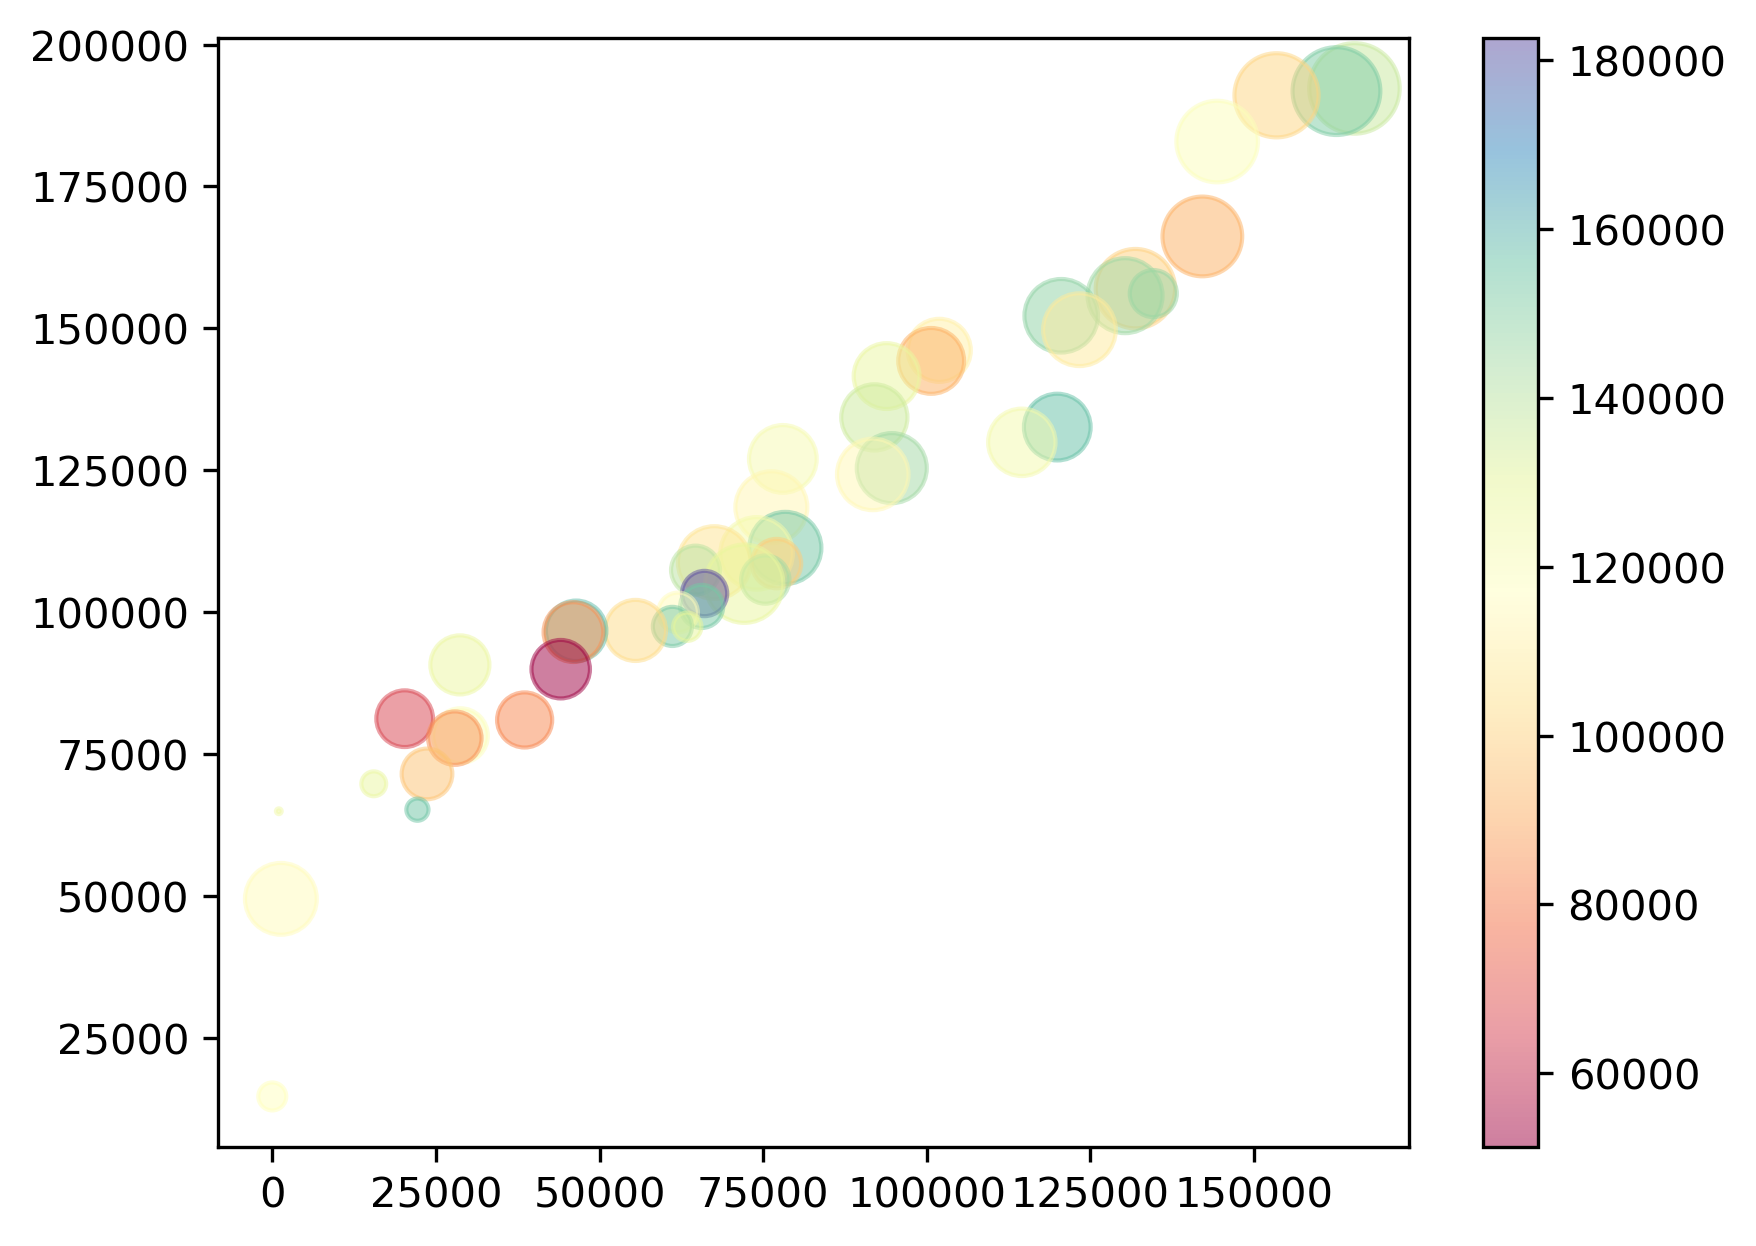

In [ ]:
# 네 가지 요소의 정보를 포함한 산점도 시각화

plt.scatter(
    df['R&D Spend'],                     # x축 변수
    df['Profit'],                        # y축 변수
    s=df['Marketing Spend'] * 0.001,     # 점 크기 (size): 마케팅 비용 → 클수록 점이 큼
    c=df['Administration'],              # 점 색상 (color): 운영비용 → 값에 따라 색이 달라짐
    alpha=0.5,                           # 점 투명도: 50% (겹침 구간도 식별 가능하게 함)
    cmap='Spectral'                      # 색상 맵: Spectral (밝은 빨강~파랑 계열로 연속값 표현)
)

plt.colorbar()
# 색상 값에 해당하는 변수(=운영비) 기준 범례를 그래프 우측에 추가함
# 점 색상이 어떤 수치 범위에 해당하는지를 시각적으로 해석할 수 있게 도움을 줌

plt.show()
# 그래프를 출력함 — 이로써 4차원(두 좌표 + 크기 + 색상)의 정보를 하나의 산점도에 시각적으로 표현함